# Step 10 – Adoption & Origination Regression

**RQ2 (part 1)**: *Which city characteristics are associated with innovation-oriented roles and faster adoption within the ecosystem of prominent open-AI projects?*

### Modelling strategy

Due to the binary nature of the adoption lag variable (0 = originator, 1 = non-originator), we adapt the analysis into three complementary models:

| Model | Level | DV | Method | n |
|---|---|---|---|---|
| A | City–Project | `is_originator` (0/1) | Logistic regression (clustered SE) | 27,806 |
| B | City | `originator_share` | OLS regression | 104 |
| C | City | `log(adoption_count)` | OLS regression | 104 |

This allows us to answer:
- **Model A**: What city characteristics predict whether a city is the *originator* of a project it participates in?
- **Model B**: What explains variation in cities' overall origination intensity?
- **Model C**: What drives the breadth of project adoption across cities?

In [5]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
from pathlib import Path

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.dpi': 120})

DATA = Path('..') / 'data' / 'output'
city_attr = pd.read_csv(DATA / 'city_attributes.csv')
adoption  = pd.read_csv(DATA / 'city_project_adoption_events.csv')

print(f'city_attributes: {city_attr.shape}')
print(f'adoption_events: {adoption.shape}')

city_attributes: (148, 28)
adoption_events: (39158, 6)


## 10.1 – Prepare Variables

In [6]:
# ---------- City-level dataset ----------
df_city = city_attr[city_attr['adoption_count'] > 0].copy()  # 104 active cities

# Dependent variables
df_city['originator_share'] = df_city['origination_count'] / df_city['adoption_count']
df_city['log_adoption'] = np.log1p(df_city['adoption_count'])

# Independent variables (log-transform skewed ones)
df_city['log_degree'] = np.log1p(df_city['weighted_degree'])
df_city['log_population'] = np.log1p(df_city['population_million'])
df_city['log_gdp'] = np.log(df_city['gdp_per_capita'])
df_city['log_entity'] = np.log1p(df_city['entity_count'])

print(f'City-level observations: {len(df_city)}')
print(f'\noriginator_share: mean={df_city["originator_share"].mean():.4f}, '
      f'std={df_city["originator_share"].std():.4f}')
print(f'log_adoption:     mean={df_city["log_adoption"].mean():.2f}, '
      f'std={df_city["log_adoption"].std():.2f}')

City-level observations: 148

originator_share: mean=0.1111, std=0.1264
log_adoption:     mean=4.79, std=1.22


In [7]:
# ---------- City-Project level dataset ----------
# Merge city features onto adoption events
merge_cols = ['city', 'log_degree', 'log_population', 'log_gdp', 'log_entity',
              'education_tertiary_pct', 'internet_users_pct',
              'rd_expenditure_pct', 'research_capacity',
              'betweenness', 'region']

df_cp = adoption.merge(df_city[merge_cols], on='city', how='inner')
print(f'City-Project observations: {len(df_cp)}')
print(f'is_originator: {df_cp["is_originator"].value_counts().to_dict()}')

City-Project observations: 39158
is_originator: {0: 30653, 1: 8505}


## 10.2 – Model A: City–Project Logistic Regression

DV: `is_originator` (binary)  
Unit: city × project pair (n ≈ 27,800)  
Clustered standard errors at city level to account for within-city correlation.

In [8]:
# Standardise IVs for comparable coefficients
iv_cols = ['log_degree', 'log_population', 'log_gdp',
           'education_tertiary_pct', 'internet_users_pct',
           'rd_expenditure_pct', 'research_capacity',
           'betweenness', 'log_entity']

# Drop rows with NaN in model variables to keep df_cp aligned with fitted data
df_cp = df_cp.dropna(subset=iv_cols + ['is_originator']).reset_index(drop=True)

scaler = StandardScaler()
for col in iv_cols:
    df_cp[col + '_z'] = scaler.fit_transform(df_cp[[col]])

iv_z = [c + '_z' for c in iv_cols]

# Logistic regression with clustered SE
formula_a = f'is_originator ~ {" + ".join(iv_z)}'
model_a = smf.logit(formula_a, data=df_cp).fit(
    cov_type='cluster', cov_kwds={'groups': df_cp['city']},
    disp=False, maxiter=200
)

print('Model A: Logistic Regression – P(is_originator = 1)')
print(f'Observations: {model_a.nobs:.0f}')
print(f'Pseudo R²: {model_a.prsquared:.4f}')
print(f'Log-Likelihood: {model_a.llf:.1f}')
print()
print(model_a.summary2().tables[1].to_string())

Model A: Logistic Regression – P(is_originator = 1)
Observations: 38347
Pseudo R²: 0.0884
Log-Likelihood: -18412.1

                             Coef.  Std.Err.          z         P>|z|    [0.025    0.975]
Intercept                -1.443718  0.100418 -14.377114  7.203614e-47 -1.640534 -1.246903
log_degree_z             -1.629538  0.435045  -3.745676  1.799085e-04 -2.482210 -0.776865
log_population_z         -0.293071  0.145808  -2.009978  4.443356e-02 -0.578850 -0.007292
log_gdp_z                 0.545798  0.296932   1.838126  6.604387e-02 -0.036178  1.127773
education_tertiary_pct_z  0.072389  0.156676   0.462030  6.440597e-01 -0.234691  0.379469
internet_users_pct_z     -0.333243  0.397025  -0.839351  4.012722e-01 -1.111398  0.444911
rd_expenditure_pct_z      0.015845  0.087263   0.181583  8.559100e-01 -0.155187  0.186878
research_capacity_z       0.275392  0.211148   1.304259  1.921452e-01 -0.138451  0.689234
betweenness_z            -0.166212  0.096917  -1.714998  8.634556e-02 -0.3

In [9]:
# Odds ratios
odds = np.exp(model_a.params)
ci = np.exp(model_a.conf_int())
ci.columns = ['OR_lower', 'OR_upper']
odds_df = pd.DataFrame({
    'Odds Ratio': odds,
    'OR_lower': ci['OR_lower'],
    'OR_upper': ci['OR_upper'],
    'p-value': model_a.pvalues,
    'sig': ['***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else '' 
            for p in model_a.pvalues]
}).round(4)

print('Odds Ratios (Model A):')
display(odds_df)

Odds Ratios (Model A):


,Odds Ratio,OR_lower,OR_upper,p-value,sig
Intercept,0.2360,0.1939,0.2874,0.0000,***
log_degree_z,0.1960,0.0836,0.4598,0.0002,***
log_population_z,0.7460,0.5605,0.9927,0.0444,*
log_gdp_z,1.7260,0.9645,3.0888,0.0660,
education_tertiary_pct_z,1.0751,0.7908,1.4615,0.6441,
internet_users_pct_z,0.7166,0.3291,1.5604,0.4013,
rd_expenditure_pct_z,1.0160,0.8563,1.2055,0.8559,
research_capacity_z,1.3170,0.8707,1.9922,0.1921,
betweenness_z,0.8469,0.7004,1.0240,0.0863,
log_entity_z,7.1751,3.0868,16.6782,0.0000,***


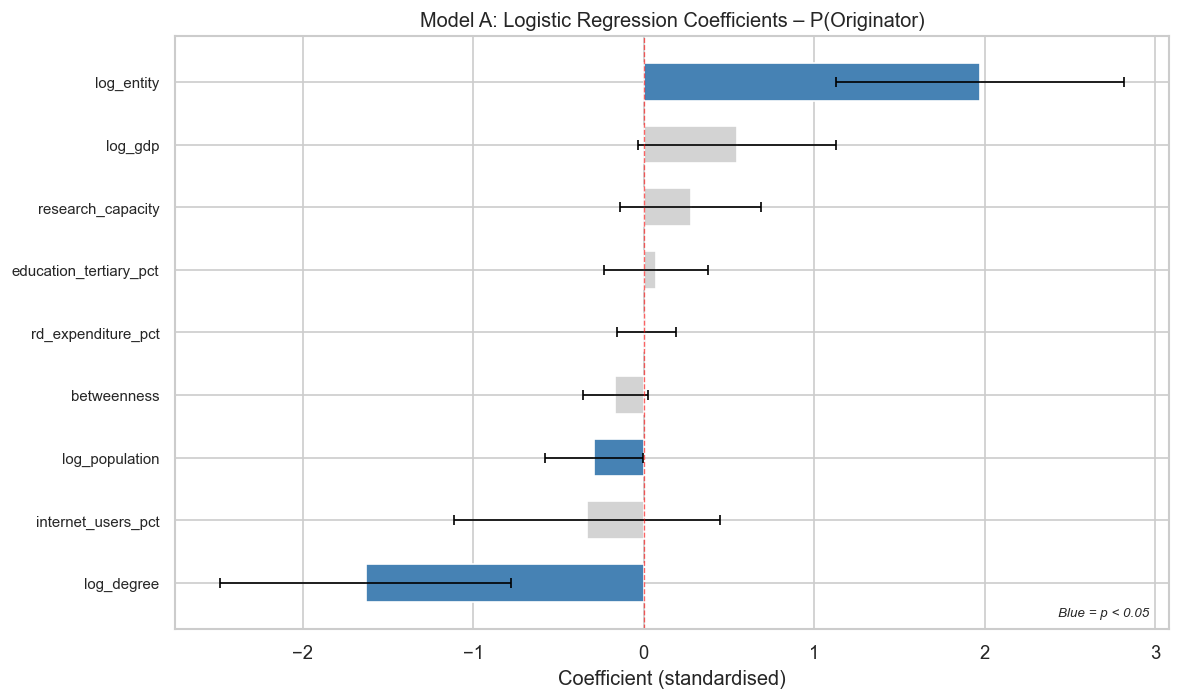

In [10]:
# Coefficient plot for Model A
coef_df = pd.DataFrame({
    'variable': iv_cols,
    'coef': model_a.params[1:].values,  # exclude intercept
    'se': model_a.bse[1:].values,
    'pval': model_a.pvalues[1:].values,
})
coef_df['ci_lower'] = coef_df['coef'] - 1.96 * coef_df['se']
coef_df['ci_upper'] = coef_df['coef'] + 1.96 * coef_df['se']
coef_df['significant'] = coef_df['pval'] < 0.05
coef_df = coef_df.sort_values('coef')

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['steelblue' if s else 'lightgrey' for s in coef_df['significant']]
ax.barh(range(len(coef_df)), coef_df['coef'], color=colors, edgecolor='white', height=0.6)
ax.errorbar(coef_df['coef'], range(len(coef_df)),
            xerr=1.96 * coef_df['se'], fmt='none', color='black', capsize=3, lw=1)
ax.axvline(0, color='red', ls='--', lw=0.8, alpha=0.6)
ax.set_yticks(range(len(coef_df)))
ax.set_yticklabels(coef_df['variable'], fontsize=9)
ax.set_xlabel('Coefficient (standardised)')
ax.set_title('Model A: Logistic Regression Coefficients – P(Originator)',
             fontsize=12)
ax.text(0.98, 0.02, 'Blue = p < 0.05', transform=ax.transAxes,
        ha='right', fontsize=8, style='italic')
plt.tight_layout()
plt.show()

## 10.3 – Model B: City-Level OLS – Originator Share

In [11]:
# Standardise IVs at city level
for col in iv_cols:
    df_city[col + '_z'] = StandardScaler().fit_transform(df_city[[col]])

formula_b = f'originator_share ~ {" + ".join(iv_z)}'
model_b = smf.ols(formula_b, data=df_city).fit(
    cov_type='HC1'  # robust SE
)

print('Model B: OLS – Originator Share')
print(f'Observations: {model_b.nobs:.0f}')
print(f'R²: {model_b.rsquared:.4f}')
print(f'Adj R²: {model_b.rsquared_adj:.4f}')
print(f'F-stat p-value: {model_b.f_pvalue:.4e}')
print()
print(model_b.summary2().tables[1].to_string())

Model B: OLS – Originator Share
Observations: 130
R²: 0.2759
Adj R²: 0.2216
F-stat p-value: 2.6734e-09

                             Coef.  Std.Err.          z         P>|z|    [0.025    0.975]
Intercept                 0.106084  0.008615  12.313832  7.631205e-35  0.089199  0.122969
log_degree_z             -0.240187  0.050857  -4.722832  2.325824e-06 -0.339864 -0.140510
log_population_z         -0.016364  0.015340  -1.066734  2.860922e-01 -0.046430  0.013702
log_gdp_z                 0.002057  0.025327   0.081212  9.352731e-01 -0.047583  0.051696
education_tertiary_pct_z -0.002986  0.011276  -0.264852  7.911234e-01 -0.025087  0.019114
internet_users_pct_z      0.017537  0.018521   0.946862  3.437091e-01 -0.018764  0.053837
rd_expenditure_pct_z      0.007867  0.011784   0.667574  5.044056e-01 -0.015230  0.030963
research_capacity_z       0.017354  0.018678   0.929089  3.528431e-01 -0.019255  0.053962
betweenness_z            -0.059857  0.026758  -2.236942  2.529011e-02 -0.112302 -0.007

## 10.4 – Model C: City-Level OLS – Adoption Breadth

In [12]:
formula_c = f'log_adoption ~ {" + ".join(iv_z)}'
model_c = smf.ols(formula_c, data=df_city).fit(
    cov_type='HC1'
)

print('Model C: OLS – log(Adoption Count)')
print(f'Observations: {model_c.nobs:.0f}')
print(f'R²: {model_c.rsquared:.4f}')
print(f'Adj R²: {model_c.rsquared_adj:.4f}')
print(f'F-stat p-value: {model_c.f_pvalue:.4e}')
print()
print(model_c.summary2().tables[1].to_string())

Model C: OLS – log(Adoption Count)
Observations: 130
R²: 0.9652
Adj R²: 0.9626
F-stat p-value: 3.9712e-88

                             Coef.  Std.Err.           z         P>|z|    [0.025    0.975]
Intercept                 4.804460  0.019397  247.690861  0.000000e+00  4.766443  4.842477
log_degree_z              0.547671  0.133940    4.088941  4.333476e-05  0.285154  0.810188
log_population_z          0.022649  0.031110    0.728031  4.665947e-01 -0.038326  0.083624
log_gdp_z                 0.044969  0.054952    0.818335  4.131662e-01 -0.062735  0.152672
education_tertiary_pct_z -0.034975  0.029515   -1.184981  2.360248e-01 -0.092823  0.022874
internet_users_pct_z     -0.003081  0.041730   -0.073825  9.411494e-01 -0.084869  0.078708
rd_expenditure_pct_z      0.041055  0.027358    1.500656  1.334445e-01 -0.012566  0.094676
research_capacity_z       0.032672  0.032415    1.007933  3.134868e-01 -0.030860  0.096204
betweenness_z             0.056521  0.054524    1.036629  2.999088e-01 -0.

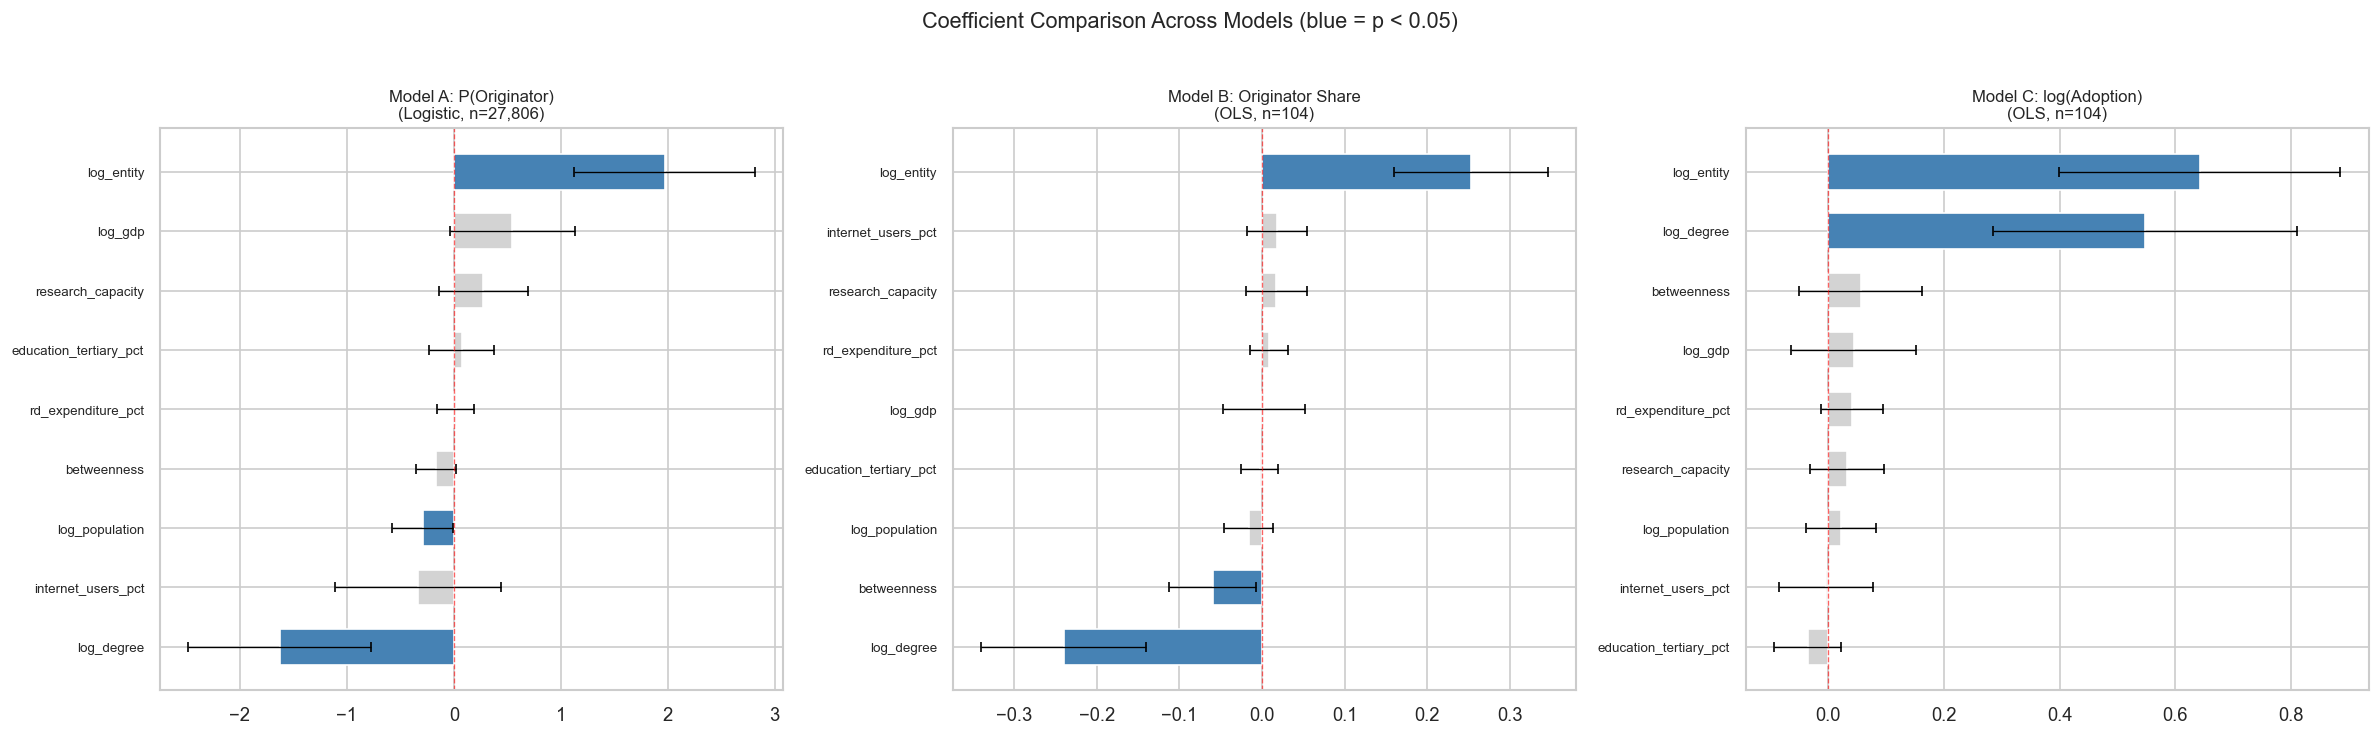

In [13]:
# Coefficient comparison across all three models
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (model, title) in zip(axes, [
    (model_a, 'Model A: P(Originator)\n(Logistic, n=27,806)'),
    (model_b, 'Model B: Originator Share\n(OLS, n=104)'),
    (model_c, 'Model C: log(Adoption)\n(OLS, n=104)'),
]):
    params = model.params[1:]  # exclude intercept
    se = model.bse[1:]
    pvals = model.pvalues[1:]

    sorted_idx = params.argsort()
    names = [iv_cols[i] for i in sorted_idx]
    vals = params.values[sorted_idx]
    errs = se.values[sorted_idx]
    sigs = pvals.values[sorted_idx] < 0.05

    colors = ['steelblue' if s else 'lightgrey' for s in sigs]
    ax.barh(range(len(names)), vals, color=colors, edgecolor='white', height=0.6)
    ax.errorbar(vals, range(len(names)),
                xerr=1.96 * errs, fmt='none', color='black', capsize=3, lw=0.8)
    ax.axvline(0, color='red', ls='--', lw=0.8, alpha=0.6)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names, fontsize=8)
    ax.set_title(title, fontsize=10)

plt.suptitle('Coefficient Comparison Across Models (blue = p < 0.05)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 10.5 – Diagnostics

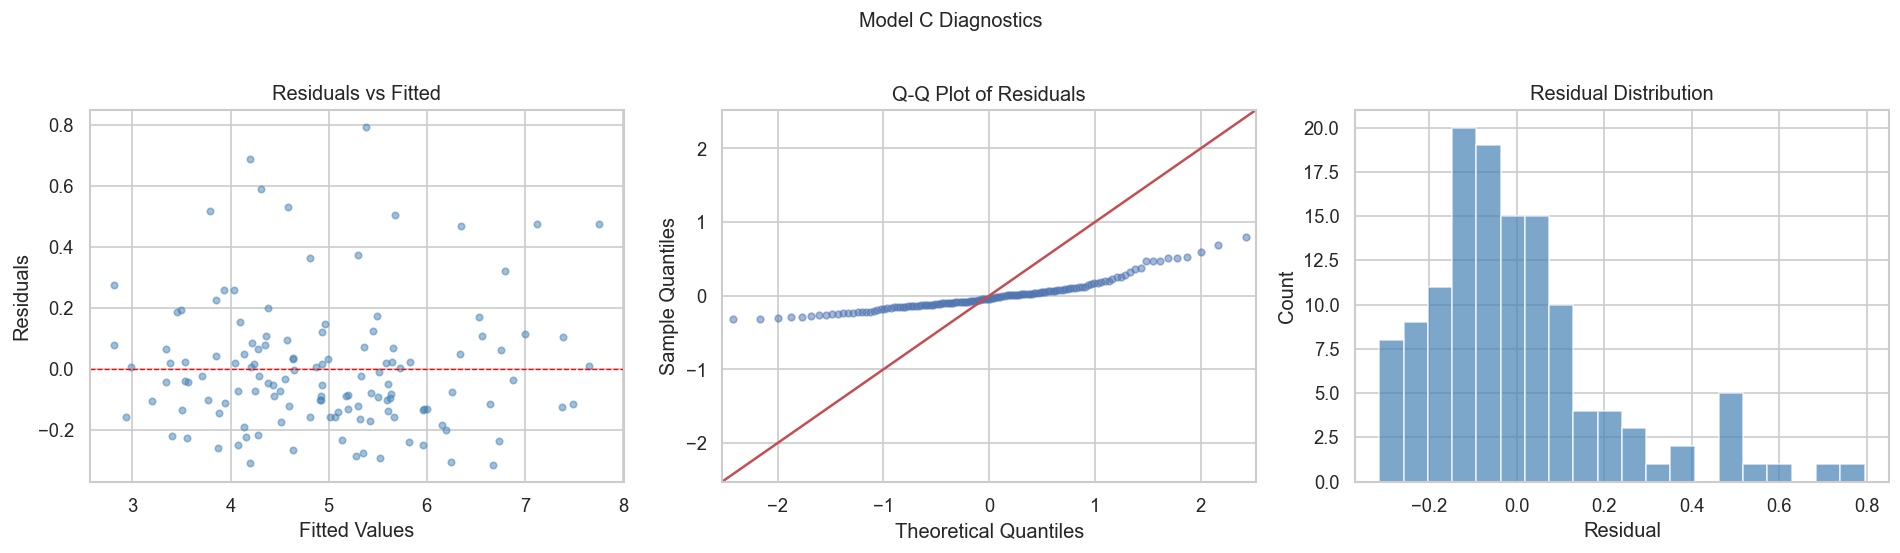

Variance Inflation Factors:


,Variable,VIF
0,log_degree,37.50
8,log_entity,28.27
2,log_gdp,9.90
4,internet_users_pct,5.92
7,betweenness,4.00
1,log_population,2.26
6,research_capacity,2.21
5,rd_expenditure_pct,2.15
3,education_tertiary_pct,2.02



⚠️  Variables with VIF > 10 (potential multicollinearity):
  Variable       VIF
log_degree 37.503921
log_entity 28.272844


In [14]:
# Residual diagnostics for Model C (OLS)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Residuals vs fitted
resid = model_c.resid
fitted = model_c.fittedvalues
axes[0].scatter(fitted, resid, s=15, alpha=0.5, color='steelblue')
axes[0].axhline(0, color='red', ls='--', lw=0.8)
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')

# Q-Q plot
sm.qqplot(resid, line='45', ax=axes[1], markersize=4, alpha=0.5)
axes[1].set_title('Q-Q Plot of Residuals')

# Residual histogram
axes[2].hist(resid, bins=20, edgecolor='white', color='steelblue', alpha=0.7)
axes[2].set_xlabel('Residual')
axes[2].set_ylabel('Count')
axes[2].set_title('Residual Distribution')

plt.suptitle('Model C Diagnostics', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# VIF check
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df_city[iv_z].dropna()
X_vif_const = sm.add_constant(X_vif)
vif_data = pd.DataFrame({
    'Variable': iv_cols,
    'VIF': [variance_inflation_factor(X_vif_const.values, i+1)
            for i in range(len(iv_cols))]
}).sort_values('VIF', ascending=False)

print('Variance Inflation Factors:')
display(vif_data.round(2))

high_vif = vif_data[vif_data['VIF'] > 10]
if len(high_vif) > 0:
    print('\n⚠️  Variables with VIF > 10 (potential multicollinearity):')
    print(high_vif.to_string(index=False))
else:
    print('\n✓ No severe multicollinearity (all VIF < 10)')

## 10.6 – Summary of Findings

In [15]:
# Consolidated results table
results = pd.DataFrame({
    'Variable': iv_cols,
    'A: Logit coef': model_a.params[1:].values.round(4),
    'A: p-val': model_a.pvalues[1:].values.round(4),
    'B: OLS coef': model_b.params[1:].values.round(4),
    'B: p-val': model_b.pvalues[1:].values.round(4),
    'C: OLS coef': model_c.params[1:].values.round(4),
    'C: p-val': model_c.pvalues[1:].values.round(4),
})

def _sig(p):
    if p < 0.001: return '***'
    if p < 0.01: return '**'
    if p < 0.05: return '*'
    if p < 0.1: return '.'
    return ''

for m in ['A', 'B', 'C']:
    results[f'{m}: sig'] = results[f'{m}: p-val'].apply(_sig)

print('=' * 80)
print('CONSOLIDATED REGRESSION RESULTS')
print('=' * 80)
display(results)

print(f'\nModel A – Pseudo R² = {model_a.prsquared:.4f}')
print(f'Model B – R² = {model_b.rsquared:.4f}, Adj R² = {model_b.rsquared_adj:.4f}')
print(f'Model C – R² = {model_c.rsquared:.4f}, Adj R² = {model_c.rsquared_adj:.4f}')

print('''
Key interpretations:
- Model A reveals which city characteristics raise the odds of being a project
  originator rather than a non-originating adopter.
- Model B identifies what drives a higher share of origination among adopted
  projects — i.e., innovation intensity.
- Model C explains what determines the breadth of project adoption — i.e.,
  how many prominent projects a city participates in.
- Significant positive coefficients in Model A/B point to factors enabling
  innovation-oriented roles; significant positive coefficients in Model C
  point to factors enabling faster and broader adoption.
''')

CONSOLIDATED REGRESSION RESULTS


,Variable,A: Logit coef,A: p-val,B: OLS coef,B: p-val,C: OLS coef,C: p-val,A: sig,B: sig,C: sig
0,log_degree,-1.6295,0.0002,-0.2402,0.0000,0.5477,0.0000,***,***,***
1,log_population,-0.2931,0.0444,-0.0164,0.2861,0.0226,0.4666,*,,
2,log_gdp,0.5458,0.0660,0.0021,0.9353,0.0450,0.4132,.,,
3,education_tertiary_pct,0.0724,0.6441,-0.0030,0.7911,-0.0350,0.2360,,,
4,internet_users_pct,-0.3332,0.4013,0.0175,0.3437,-0.0031,0.9411,,,
5,rd_expenditure_pct,0.0158,0.8559,0.0079,0.5044,0.0411,0.1334,,,
6,research_capacity,0.2754,0.1921,0.0174,0.3528,0.0327,0.3135,,,
7,betweenness,-0.1662,0.0863,-0.0599,0.0253,0.0565,0.2999,.,*,
8,log_entity,1.9706,0.0000,0.2524,0.0000,0.6415,0.0000,***,***,***



Model A – Pseudo R² = 0.0884
Model B – R² = 0.2759, Adj R² = 0.2216
Model C – R² = 0.9652, Adj R² = 0.9626

Key interpretations:
- Model A reveals which city characteristics raise the odds of being a project
  originator rather than a non-originating adopter.
- Model B identifies what drives a higher share of origination among adopted
  projects — i.e., innovation intensity.
- Model C explains what determines the breadth of project adoption — i.e.,
  how many prominent projects a city participates in.
- Significant positive coefficients in Model A/B point to factors enabling
  innovation-oriented roles; significant positive coefficients in Model C
  point to factors enabling faster and broader adoption.

